# Harsh Driving Event Detection Project

This notebook trains and deploys models to detect:
- sudden_acceleration
- sudden_braking
- harsh_left_turn
- harsh_right_turn
- harsh_left_lane_change
- harsh_right_lane_change

Input stream schema expected from CARLA/manual drive:
`sr_no, timestamp, road_type, harsh_event, acc_x, acc_y, acc_z, gyro_x, gyro_y, gyro_z, mag_x, mag_y, mag_z, event_class`

## 1. Environment Setup and Reproducibility

In [16]:
# If needed, uncomment and run once.
%pip install -q pandas numpy scikit-learn imbalanced-learn matplotlib seaborn torch joblib

from pathlib import Path
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import GroupShuffleSplit, GroupKFold
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.utils.class_weight import compute_class_weight
from sklearn.calibration import CalibratedClassifierCV

from imblearn.over_sampling import RandomOverSampler

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import sys

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

ROOT = Path.cwd().resolve().parent if (Path.cwd().name == 'notebooks') else Path.cwd()
DATASET_DIR = ROOT / 'dataset'
ARTIFACT_DIR = ROOT / 'artifacts'
SRC_DIR = ROOT / 'src'
ARTIFACT_DIR.mkdir(exist_ok=True)

if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))

sns.set_style('whitegrid')
print(f'ROOT={ROOT}')
print(f'DATASET_DIR exists: {DATASET_DIR.exists()}')
print(f'ARTIFACT_DIR={ARTIFACT_DIR}')

Note: you may need to restart the kernel to use updated packages.
ROOT=C:\Users\vigne\Downloads\carla-project-main
DATASET_DIR exists: True
ARTIFACT_DIR=C:\Users\vigne\Downloads\carla-project-main\artifacts


## 2. Dataset Discovery and File-Level Metadata Parsing

In [17]:
def parse_speed(file_name: str):
    lowered = file_name.lower()
    if '20kmph' in lowered:
        return 20
    if '40kmph' in lowered:
        return 40
    if '60kmph' in lowered:
        return 60
    return 0

csv_files = sorted(DATASET_DIR.glob('*.csv'))
file_index = pd.DataFrame({
    'file_name': [f.name for f in csv_files],
    'road_type_from_name': [f.name.split('_')[0] for f in csv_files],
    'speed_kmph': [parse_speed(f.name) for f in csv_files],
})
file_index['file_id'] = np.arange(len(file_index))
file_index.head(10)

,file_name,road_type_from_name,speed_kmph,file_id
0,paved_safe-acc_const-acc-at-60kmph_22-3-2023_2...,paved,60,0
1,paved_safe-acc_uniform-acc_28-2-2023_16-2-56.csv,paved,0,1
2,paved_safe-no-movement_zero-acc_22-3-2023_19-4...,paved,0,2
3,paved_safe_acc_const-acc-at-20kmph_28-2-2023_1...,paved,20,3
4,paved_safe_acc_const-acc-at-40kmph_28-2-2023_1...,paved,40,4
5,paved_sudden-acc_const-acc-at-20kmph_20-2-2023...,paved,20,5
6,paved_sudden-acc_const-acc-at-20kmph_20-2-2023...,paved,20,6
7,paved_sudden-acc_const-acc-at-20kmph_20-2-2023...,paved,20,7
8,paved_sudden-acc_const-acc-at-20kmph_20-2-2023...,paved,20,8
9,paved_sudden-acc_const-acc-at-20kmph_22-3-2023...,paved,20,9


## 3. CSV Ingestion and Schema Validation

In [18]:
EXPECTED_COLUMNS = [
    'sr_no', 'timestamp', 'road_type', 'harsh_event',
    'acc_x', 'acc_y', 'acc_z',
    'gyro_x', 'gyro_y', 'gyro_z',
    'mag_x', 'mag_y', 'mag_z',
    'event_class',
]

imu_cols = ['acc_x', 'acc_y', 'acc_z', 'gyro_x', 'gyro_y', 'gyro_z', 'mag_x', 'mag_y', 'mag_z']

def robust_timestamp_parse(series: pd.Series) -> pd.Series:
    # Handles both formats: 22-3-2023_20:14:29:15484 and 22-3-2023 20:14:29:15484
    s = series.astype(str).str.replace('_', ' ', regex=False)
    return pd.to_datetime(s, format='%d-%m-%Y %H:%M:%S:%f', errors='coerce')

frames = []
schema_issues = []
for fp in csv_files:
    df = pd.read_csv(fp)
    missing = [c for c in EXPECTED_COLUMNS if c not in df.columns]
    if missing:
        schema_issues.append((fp.name, missing))
        continue

    for c in imu_cols:
        df[c] = pd.to_numeric(df[c], errors='coerce')

    df['event_class'] = pd.to_numeric(df['event_class'], errors='coerce').fillna(0).astype(int)
    df['timestamp_parsed'] = robust_timestamp_parse(df['timestamp'])
    df = df.sort_values('timestamp_parsed', kind='mergesort').reset_index(drop=True)

    missing_ratio = df[imu_cols].isna().mean().mean()
    df = df.dropna(subset=imu_cols).copy()

    df['source_file'] = fp.name
    frames.append(df)

print('Schema issues:', schema_issues if schema_issues else 'None')
raw_df = pd.concat(frames, ignore_index=True)
print('Rows:', len(raw_df), 'Files:', raw_df['source_file'].nunique())
print('Global missing ratio over IMU before drop:', round(missing_ratio, 5))
raw_df.head()

Schema issues: None
Rows: 32987 Files: 54
Global missing ratio over IMU before drop: 0.0


,sr_no,timestamp,road_type,harsh_event,acc_x,acc_y,acc_z,gyro_x,gyro_y,gyro_z,mag_x,mag_y,mag_z,event_class,timestamp_parsed,source_file
0,1,22-3-2023 20:32:39:320352,paved,sudden-acc,-3.353295,-4.104586,2.833607,0.037641,-0.069241,0.131234,-85.886642,-79.899757,81.319404,0,2023-03-22 20:32:39.320352,paved_safe-acc_const-acc-at-60kmph_22-3-2023_2...
1,2,22-3-2023 20:32:39:685071,paved,sudden-acc,-2.165347,-2.073578,-0.260807,-0.017754,-0.196808,0.142686,-85.886642,-79.899757,81.319404,0,2023-03-22 20:32:39.685071,paved_safe-acc_const-acc-at-60kmph_22-3-2023_2...
2,3,22-3-2023 20:32:39:697380,paved,sudden-acc,-2.510235,-1.661629,14.320298,0.070931,0.002666,0.153073,-89.009796,-81.466423,81.319404,0,2023-03-22 20:32:39.697380,paved_safe-acc_const-acc-at-60kmph_22-3-2023_2...
3,4,22-3-2023 20:32:39:705378,paved,sudden-acc,-1.303127,3.090163,5.219082,0.060544,0.144881,0.147213,-89.009796,-81.466423,81.319404,0,2023-03-22 20:32:39.705378,paved_safe-acc_const-acc-at-60kmph_22-3-2023_2...
4,5,22-3-2023 20:32:39:737391,paved,sudden-acc,6.140707,-2.351405,-1.496656,-0.005237,-0.019972,0.128571,-84.325073,-81.466423,82.771537,0,2023-03-22 20:32:39.737391,paved_safe-acc_const-acc-at-60kmph_22-3-2023_2...


## 4. Label Strategy for Multi-Class Harsh Event Detection

In [19]:
from harsh_event_model import normalize_event_name, load_row_labeled_data

row_labeled_df = load_row_labeled_data(DATASET_DIR)
print('Row-level labels:')
print(row_labeled_df['event_label'].value_counts())

class_to_id = {
    'safe': 0,
    'sudden_acceleration': 1,
    'sudden_braking': 2,
    'harsh_left_turn': 3,
    'harsh_right_turn': 4,
    'harsh_left_lane_change': 5,
    'harsh_right_lane_change': 6,
}
id_to_class = {v: k for k, v in class_to_id.items()}
row_labeled_df['class_id'] = row_labeled_df['event_label'].map(class_to_id).fillna(0).astype(int)
row_labeled_df[['source_file', 'harsh_event', 'event_class', 'event_label', 'class_id']].head()

Row-level labels:
event_label
safe                       22543
sudden_acceleration         2860
harsh_right_lane_change     2127
harsh_left_lane_change      2062
harsh_left_turn             1033
sudden_braking               836
harsh_right_turn             582
Name: count, dtype: int64


,source_file,harsh_event,event_class,event_label,class_id
0,paved_safe-acc_uniform-acc_28-2-2023_16-2-56.csv,uniform-accel,0,safe,0
1,paved_safe-acc_uniform-acc_28-2-2023_16-2-56.csv,uniform-accel,0,safe,0
2,paved_safe-acc_uniform-acc_28-2-2023_16-2-56.csv,uniform-accel,0,safe,0
3,paved_safe-acc_uniform-acc_28-2-2023_16-2-56.csv,uniform-accel,0,safe,0
4,paved_safe-acc_uniform-acc_28-2-2023_16-2-56.csv,uniform-accel,0,safe,0


## 5. Signal Cleaning and Sensor Feature Engineering

In [20]:
clean_df = row_labeled_df.copy()

# Light denoising: rolling median over a short window.
for col in imu_cols:
    clean_df[col] = (
        clean_df.groupby('source_file')[col]
        .transform(lambda s: s.rolling(window=3, min_periods=1, center=True).median())
    )

clean_df['acc_mag'] = np.sqrt(clean_df['acc_x']**2 + clean_df['acc_y']**2 + clean_df['acc_z']**2)
clean_df['gyro_mag'] = np.sqrt(clean_df['gyro_x']**2 + clean_df['gyro_y']**2 + clean_df['gyro_z']**2)
clean_df['mag_mag'] = np.sqrt(clean_df['mag_x']**2 + clean_df['mag_y']**2 + clean_df['mag_z']**2)

for axis in ['acc_x', 'acc_y', 'acc_z']:
    clean_df[f'{axis}_jerk'] = clean_df.groupby('source_file')[axis].diff().fillna(0.0)

clean_df['lat_long_ratio'] = clean_df['acc_y'].abs() / (clean_df['acc_x'].abs() + 1e-6)
clean_df[['acc_mag', 'gyro_mag', 'mag_mag', 'acc_x_jerk', 'lat_long_ratio']].describe().T[['mean', 'std', 'min', 'max']]

,mean,std,min,max
acc_mag,3.146987,1.918425,0.131686,33.004681
gyro_mag,0.106603,0.125188,0.001439,1.484753
mag_mag,124.322779,57.618599,31.032744,628.072902
acc_x_jerk,0.000822,1.262574,-21.124395,16.506726
lat_long_ratio,6.831795,48.722908,0.000037,3002.531029


## 6. Windowing Time-Series Data for Sequence Learning

In [21]:
from collections import Counter

feature_cols_stream = imu_cols + ['acc_mag', 'gyro_mag', 'mag_mag', 'acc_x_jerk', 'acc_y_jerk', 'acc_z_jerk', 'lat_long_ratio']
WINDOW_SIZE = 25
STEP_SIZE = 5

def extract_window_stats(window_2d: np.ndarray):
    # window_2d shape: [T, F]
    feats = []
    eps = 1e-6
    for i in range(window_2d.shape[1]):
        x = window_2d[:, i]
        dx = np.diff(x)
        feats.extend([
            np.mean(x), np.std(x), np.min(x), np.max(x),
            np.sqrt(np.mean(x ** 2)), np.sum(x ** 2),
            np.mean(dx) if len(dx) else 0.0,
            np.std(dx) if len(dx) else 0.0,
        ])
    return np.asarray(feats, dtype=np.float32)

def build_windows(df: pd.DataFrame, window_size=25, step_size=5, min_event_ratio=0.20):
    x_tab, x_seq, y, groups, t0, t1 = [], [], [], [], [], []
    for file_name, g in df.groupby('source_file'):
        g = g.reset_index(drop=True)
        if len(g) < window_size:
            continue
        values = g[feature_cols_stream].to_numpy(dtype=np.float32)
        labels = g['event_label'].to_numpy()
        times = g['timestamp'].astype(str).to_numpy()

        for start in range(0, len(g) - window_size + 1, step_size):
            end = start + window_size
            w = values[start:end]
            wl = labels[start:end]
            non_safe = wl[wl != 'safe']
            if len(non_safe) == 0 or (len(non_safe) / window_size) < min_event_ratio:
                target = 'safe'
            else:
                target = Counter(non_safe).most_common(1)[0][0]

            x_seq.append(w)
            x_tab.append(extract_window_stats(w))
            y.append(target)
            groups.append(file_name)
            t0.append(times[start])
            t1.append(times[end - 1])

    x_tab = np.vstack(x_tab).astype(np.float32)
    x_seq = np.stack(x_seq).astype(np.float32)
    y = np.array(y)
    groups = np.array(groups)
    return x_tab, x_seq, y, groups, np.array(t0), np.array(t1)

x_tab, x_seq, y_win, groups, start_times, end_times = build_windows(
    clean_df,
    window_size=WINDOW_SIZE,
    step_size=STEP_SIZE,
)

print('x_tab shape:', x_tab.shape)
print('x_seq shape:', x_seq.shape)
print(pd.Series(y_win).value_counts())

x_tab shape: (6173, 128)
x_seq shape: (6173, 25, 16)
safe                       4073
sudden_acceleration         615
harsh_right_lane_change     474
harsh_left_lane_change      467
harsh_left_turn             222
sudden_braking              192
harsh_right_turn            130
Name: count, dtype: int64


## 7. Leakage-Safe Train/Validation/Test Split by File

In [35]:
all_labels = sorted(pd.Series(y_win).unique().tolist())
required_eval_labels = [lbl for lbl in all_labels if lbl != 'safe']


def labels_present(arr):
    return set(pd.Series(arr).unique().tolist())


def required_coverage(arr, required):
    present = labels_present(arr)
    return sum(lbl in present for lbl in required)


best = None
best_score = (-1, -1, -1, -1)

# Try multiple group-preserving random splits and prefer broad non-safe class coverage in val/test.
for split_seed in range(SEED, SEED + 20000):
    gss_1 = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=split_seed)
    train_idx_cand, temp_idx_cand = next(gss_1.split(x_tab, y_win, groups=groups))

    gss_2 = GroupShuffleSplit(n_splits=1, test_size=0.50, random_state=split_seed)
    val_rel_idx, test_rel_idx = next(
        gss_2.split(x_tab[temp_idx_cand], y_win[temp_idx_cand], groups=groups[temp_idx_cand])
    )
    val_idx_cand = temp_idx_cand[val_rel_idx]
    test_idx_cand = temp_idx_cand[test_rel_idx]

    y_val_cand = y_win[val_idx_cand]
    y_test_cand = y_win[test_idx_cand]

    cov_val = required_coverage(y_val_cand, required_eval_labels)
    cov_test = required_coverage(y_test_cand, required_eval_labels)
    diversity = len(labels_present(y_val_cand)) + len(labels_present(y_test_cand))

    # Prioritize minimum coverage across val/test, then total coverage, then diversity.
    score = (min(cov_val, cov_test), cov_val + cov_test, diversity, -abs(cov_val - cov_test))

    if score > best_score:
        best_score = score
        best = (train_idx_cand, val_idx_cand, test_idx_cand, split_seed, cov_val, cov_test)

    if cov_val == len(required_eval_labels) and cov_test == len(required_eval_labels):
        break

if best is None:
    raise RuntimeError('Unable to create a train/val/test split.')

train_idx, val_idx, test_idx, chosen_seed, cov_val_best, cov_test_best = best
print(f'Chosen group split seed: {chosen_seed}')

x_tab_train, x_tab_val, x_tab_test = x_tab[train_idx], x_tab[val_idx], x_tab[test_idx]
x_seq_train, x_seq_val, x_seq_test = x_seq[train_idx], x_seq[val_idx], x_seq[test_idx]
y_train_raw, y_val_raw, y_test_raw = y_win[train_idx], y_win[val_idx], y_win[test_idx]


def split_distribution(name, arr, label_order):
    vc = pd.Series(arr).value_counts(normalize=True).mul(100).reindex(label_order, fill_value=0.0).round(2)
    print(f'\n{name} distribution (%)')
    print(vc)


split_distribution('Train', y_train_raw, all_labels)
split_distribution('Validation', y_val_raw, all_labels)
split_distribution('Test', y_test_raw, all_labels)

if required_eval_labels:
    val_present = sorted(labels_present(y_val_raw).intersection(required_eval_labels))
    test_present = sorted(labels_present(y_test_raw).intersection(required_eval_labels))
    print('\nRequired non-safe labels:', required_eval_labels)
    print(f'Validation coverage: {len(val_present)}/{len(required_eval_labels)} -> {val_present}')
    print(f'Test coverage      : {len(test_present)}/{len(required_eval_labels)} -> {test_present}')

split_col = np.full(len(y_win), 'test', dtype=object)
split_col[train_idx] = 'train'
split_col[val_idx] = 'val'

split_manifest = pd.DataFrame({
    'split': split_col,
    'group_file': groups,
    'window_start': start_times,
    'window_end': end_times,
    'label': y_win,
})
split_manifest.to_csv(ARTIFACT_DIR / 'split_manifest.csv', index=False)
print('Saved split manifest:', ARTIFACT_DIR / 'split_manifest.csv')

Chosen group split seed: 92

Train distribution (%)
harsh_left_lane_change      8.80
harsh_left_turn             3.71
harsh_right_lane_change     9.07
harsh_right_turn            0.79
safe                       64.95
sudden_acceleration         8.97
sudden_braking              3.71
Name: proportion, dtype: float64

Validation distribution (%)
harsh_left_lane_change      4.85
harsh_left_turn             3.20
harsh_right_lane_change     5.54
harsh_right_turn            2.68
safe                       63.72
sudden_acceleration        18.27
sudden_braking              1.73
Name: proportion, dtype: float64

Test distribution (%)
harsh_left_lane_change      5.58
harsh_left_turn             3.58
harsh_right_lane_change     4.32
harsh_right_turn            7.05
safe                       73.16
sudden_acceleration         4.11
sudden_braking              2.21
Name: proportion, dtype: float64

Required non-safe labels: ['harsh_left_lane_change', 'harsh_left_turn', 'harsh_right_lane_change', 'har

## 8. Class Imbalance Handling and Sample Weighting

In [23]:
label_order = sorted(pd.Series(y_win).unique().tolist())
label_to_idx = {c: i for i, c in enumerate(label_order)}
idx_to_label = {i: c for c, i in label_to_idx.items()}

y_train = np.array([label_to_idx[v] for v in y_train_raw], dtype=np.int64)
y_val = np.array([label_to_idx[v] for v in y_val_raw], dtype=np.int64)
y_test = np.array([label_to_idx[v] for v in y_test_raw], dtype=np.int64)

weights = compute_class_weight(class_weight='balanced', classes=np.arange(len(label_order)), y=y_train)
class_weight_tensor = torch.tensor(weights, dtype=torch.float32)
print('Class weights:', {idx_to_label[i]: float(w) for i, w in enumerate(weights)})

# Optional oversampling for tabular baseline.
ros = RandomOverSampler(random_state=SEED)
x_tab_train_bal, y_train_bal = ros.fit_resample(x_tab_train, y_train)
print('Before balancing:', np.bincount(y_train))
print('After balancing :', np.bincount(y_train_bal))

Class weights: {'harsh_left_lane_change': 1.747286148501954, 'harsh_left_turn': 2.5894465894465895, 'harsh_right_lane_change': 1.8909774436090225, 'harsh_right_turn': 5.865889212827988, 'safe': 0.2170910660336642, 'sudden_acceleration': 2.053061224489796, 'sudden_braking': 4.01998001998002}
Before balancing: [ 329  222  304   98 2648  280  143]
After balancing : [2648 2648 2648 2648 2648 2648 2648]


## 9. Model 1: Tree-Based Baseline (Random Forest)

Random Forest validation classification report
                         precision    recall  f1-score   support

 harsh_left_lane_change     0.3269    0.6071    0.4250        56
        harsh_left_turn     0.0000    0.0000    0.0000        37
harsh_right_lane_change     0.0000    0.0000    0.0000        64
       harsh_right_turn     0.0000    0.0000    0.0000        31
                   safe     0.7376    0.9511    0.8309       736
    sudden_acceleration     0.8571    0.1706    0.2846       211
         sudden_braking     0.6500    0.6500    0.6500        20

               accuracy                         0.6779      1155
              macro avg     0.3674    0.3398    0.3129      1155
           weighted avg     0.6537    0.6779    0.6133      1155

Random Forest test classification report
                         precision    recall  f1-score   support

 harsh_left_lane_change     0.4057    0.8113    0.5409        53
        harsh_left_turn     0.0000    0.0000    0.0000        3

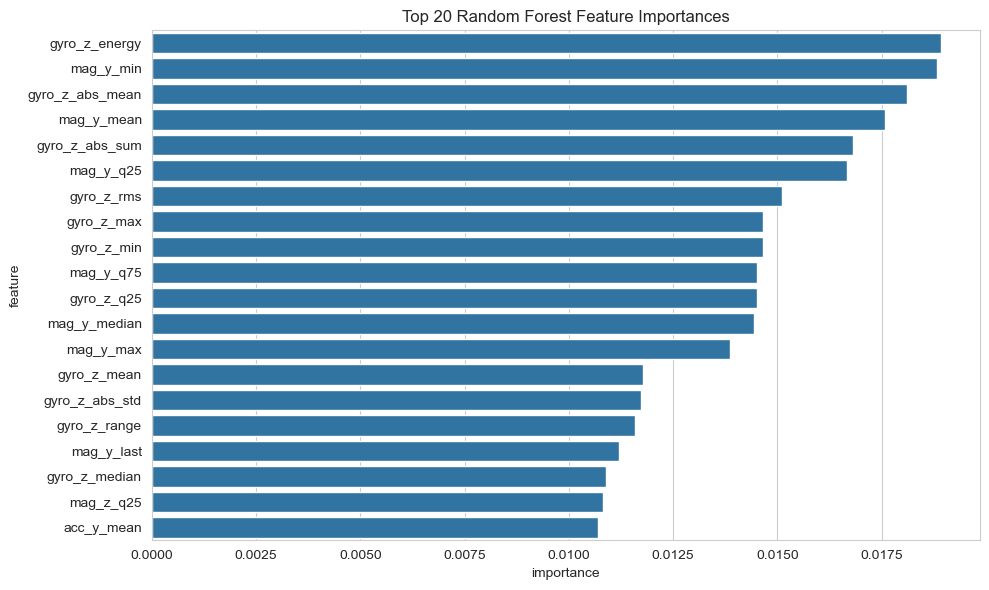

In [36]:
from harsh_event_model import build_window_dataset, train_event_model_from_splits, save_model_bundle

# Build RF features using the same window settings used for sequence modeling.
X_df, y_series = build_window_dataset(clean_df, window_size=WINDOW_SIZE, step_size=STEP_SIZE, min_event_ratio=0.20)

if len(X_df) != len(y_win):
    raise ValueError(f'Window count mismatch between RF ({len(X_df)}) and split indices ({len(y_win)}).')

X_train_rf = X_df.iloc[train_idx].reset_index(drop=True)
X_val_rf = X_df.iloc[val_idx].reset_index(drop=True)
X_test_rf = X_df.iloc[test_idx].reset_index(drop=True)
y_train_rf = y_series.iloc[train_idx].reset_index(drop=True)
y_val_rf = y_series.iloc[val_idx].reset_index(drop=True)
y_test_rf = y_series.iloc[test_idx].reset_index(drop=True)

artifacts = train_event_model_from_splits(
    x_train=X_train_rf,
    y_train=y_train_rf,
    x_val=X_val_rf,
    y_val=y_val_rf,
    x_test=X_test_rf,
    y_test=y_test_rf,
    random_state=SEED,
 )

print('Random Forest validation classification report')
print(artifacts.val_class_report)
print('Random Forest test classification report')
print(artifacts.class_report)

rf_bundle_path = ARTIFACT_DIR / 'harsh_event_rf.joblib'
save_model_bundle(
    output_path=rf_bundle_path,
    artifacts=artifacts,
    window_size=WINDOW_SIZE,
    step_size=STEP_SIZE,
    min_event_ratio=0.20,
 )
print('Saved:', rf_bundle_path)

# Feature importance from RF stage inside the pipeline.
rf_model = artifacts.model.named_steps['rf']
fi = pd.DataFrame({'feature': artifacts.feature_columns, 'importance': rf_model.feature_importances_})
fi = fi.sort_values('importance', ascending=False).head(20)
plt.figure(figsize=(10, 6))
sns.barplot(data=fi, x='importance', y='feature')
plt.title('Top 20 Random Forest Feature Importances')
plt.tight_layout()
plt.show()

## 10. Model 2: Sequence Model (1D CNN + BiLSTM)

In [25]:
class SeqDataset(Dataset):
    def __init__(self, x, y):
        self.x = torch.tensor(x, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]


class CNNBiLSTM(nn.Module):
    def __init__(self, in_features, n_classes):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(in_channels=in_features, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Conv1d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(),
        )
        self.lstm = nn.LSTM(input_size=64, hidden_size=64, num_layers=1, batch_first=True, bidirectional=True)
        self.head = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, n_classes),
        )

    def forward(self, x):
        # x: [B, T, F]
        x = x.transpose(1, 2)              # [B, F, T]
        x = self.conv(x)                   # [B, 64, T]
        x = x.transpose(1, 2)              # [B, T, 64]
        out, _ = self.lstm(x)              # [B, T, 128]
        pooled = out.mean(dim=1)           # [B, 128]
        return self.head(pooled)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

train_ds = SeqDataset(x_seq_train, y_train)
val_ds = SeqDataset(x_seq_val, y_val)
test_ds = SeqDataset(x_seq_test, y_test)

train_loader = DataLoader(train_ds, batch_size=128, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=256, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=256, shuffle=False)

seq_model = CNNBiLSTM(in_features=x_seq.shape[-1], n_classes=len(label_order)).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weight_tensor.to(device))
optimizer = torch.optim.AdamW(seq_model.parameters(), lr=1e-3, weight_decay=1e-4)
scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())

Using device: cpu


C:\Users\vigne\AppData\Local\Temp\ipykernel_22972\2540426001.py:54: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())


## 11. Training Loops, Hyperparameter Tuning, and Checkpointing

In [26]:
def evaluate_model(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    total_loss = 0.0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss = criterion(logits, yb)
            total_loss += loss.item() * xb.size(0)
            preds = torch.argmax(logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(yb.cpu().numpy())
    avg_loss = total_loss / max(len(loader.dataset), 1)
    macro_f1 = f1_score(all_labels, all_preds, average='macro')
    return avg_loss, macro_f1, np.array(all_labels), np.array(all_preds)

best_val_f1 = -1.0
best_state = None
history = []
PATIENCE = 6
patience_count = 0
EPOCHS = 25

for epoch in range(1, EPOCHS + 1):
    seq_model.train()
    train_loss_sum = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad(set_to_none=True)
        with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
            logits = seq_model(xb)
            loss = criterion(logits, yb)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        train_loss_sum += loss.item() * xb.size(0)

    train_loss = train_loss_sum / len(train_loader.dataset)
    val_loss, val_f1, _, _ = evaluate_model(seq_model, val_loader)
    history.append({'epoch': epoch, 'train_loss': train_loss, 'val_loss': val_loss, 'val_macro_f1': val_f1})

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_state = {k: v.cpu().clone() for k, v in seq_model.state_dict().items()}
        patience_count = 0
    else:
        patience_count += 1

    print(f'Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | val_macro_f1={val_f1:.4f}')
    if patience_count >= PATIENCE:
        print('Early stopping triggered.')
        break

if best_state is not None:
    seq_model.load_state_dict(best_state)

torch.save({
    'state_dict': seq_model.state_dict(),
    'label_order': label_order,
    'window_size': WINDOW_SIZE,
    'step_size': STEP_SIZE,
    'feature_columns': feature_cols_stream,
}, ARTIFACT_DIR / 'harsh_event_cnn_bilstm.pt')

pd.DataFrame(history).to_csv(ARTIFACT_DIR / 'seq_training_history.csv', index=False)
print('Saved sequence checkpoint and training history.')

C:\Users\vigne\AppData\Local\Temp\ipykernel_22972\166667990.py:31: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):


Epoch 01 | train_loss=1.8026 | val_loss=2.0977 | val_macro_f1=0.1122


C:\Users\vigne\AppData\Local\Temp\ipykernel_22972\166667990.py:31: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):


Epoch 02 | train_loss=1.2681 | val_loss=2.2486 | val_macro_f1=0.0617


C:\Users\vigne\AppData\Local\Temp\ipykernel_22972\166667990.py:31: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):


...

Epoch 17 | train_loss=0.4389 | val_loss=3.5723 | val_macro_f1=0.2543


C:\Users\vigne\AppData\Local\Temp\ipykernel_22972\166667990.py:31: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):


Epoch 18 | train_loss=0.5052 | val_loss=2.5567 | val_macro_f1=0.3355


C:\Users\vigne\AppData\Local\Temp\ipykernel_22972\166667990.py:31: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):


Epoch 19 | train_loss=0.4946 | val_loss=2.9875 | val_macro_f1=0.2222
Early stopping triggered.
Saved sequence checkpoint and training history.


## 12. Evaluation: Per-Class Metrics, Confusion Matrix, PR Curves

Sequence model report:
                         precision    recall  f1-score   support

 harsh_left_lane_change     0.1348    0.1304    0.1326        92
        harsh_left_turn     0.0000    0.0000    0.0000         0
harsh_right_lane_change     0.1488    0.1731    0.1600       104
       harsh_right_turn     0.0000    0.0000    0.0000         0
                   safe     0.7435    0.4447    0.5566       769
    sudden_acceleration     0.0000    0.0000    0.0000       107
         sudden_braking     0.0793    0.8571    0.1452        21

              micro avg     0.3568    0.3568    0.3568      1093
              macro avg     0.1581    0.2293    0.1420      1093
           weighted avg     0.5501    0.3568    0.4207      1093



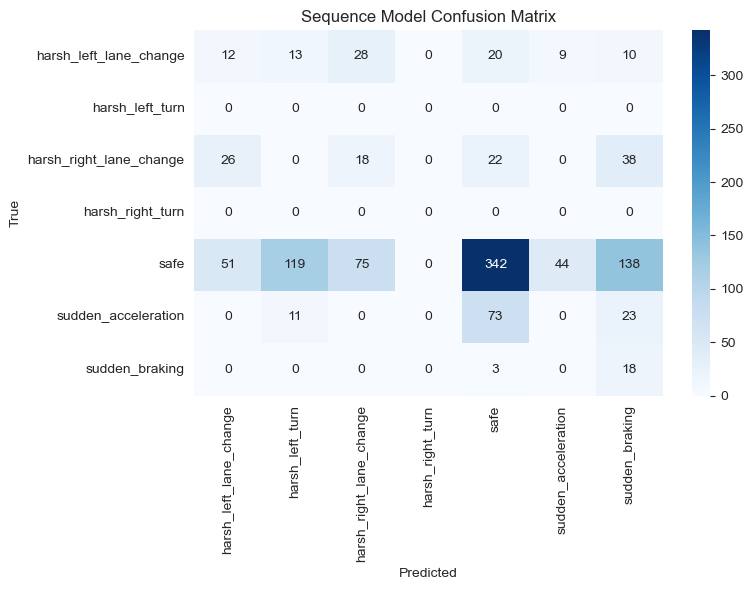

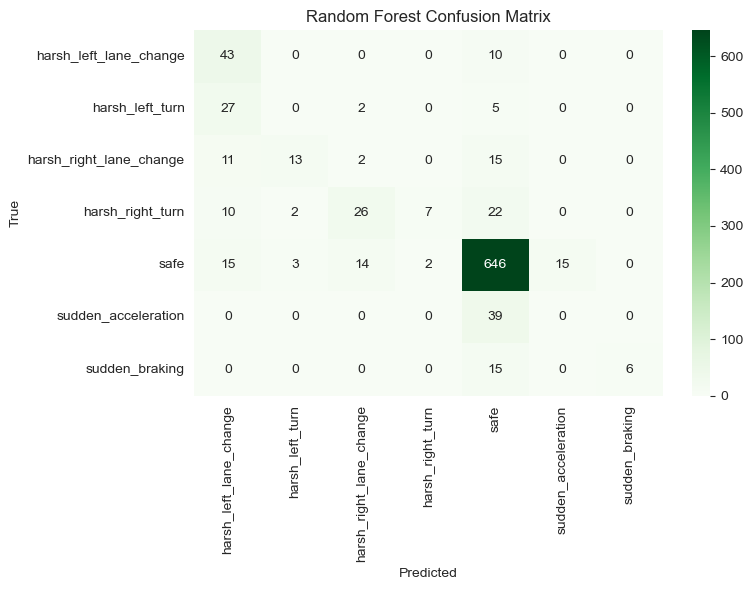

In [37]:
# Sequence model evaluation
_, _, y_true_seq, y_pred_seq = evaluate_model(seq_model, test_loader)

all_label_ids = list(range(len(label_order)))
print('Sequence model report:')
print(
    classification_report(
        y_true_seq,
        y_pred_seq,
        labels=all_label_ids,
        target_names=label_order,
        digits=4,
        zero_division=0,
    )
)

cm_seq = confusion_matrix(y_true_seq, y_pred_seq, labels=all_label_ids)
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_seq,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=label_order,
    yticklabels=label_order,
)
plt.title('Sequence Model Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()

# Baseline model confusion matrix on its own held-out split (inside train_event_model).
# We use artifacts.confusion_matrix directly from the reusable pipeline.
rf_labels = artifacts.label_encoder.inverse_transform(np.arange(artifacts.confusion_matrix.shape[0]))
plt.figure(figsize=(8, 6))
sns.heatmap(
    artifacts.confusion_matrix,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=rf_labels,
    yticklabels=rf_labels,
)
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()

## 13. Threshold Calibration and Temporal Smoothing

In [28]:
# Calibrate baseline probabilities using sigmoid (Platt scaling).
calibrated_rf = CalibratedClassifierCV(artifacts.model, method='sigmoid', cv='prefit')
calibrated_rf.fit(X_df, artifacts.label_encoder.transform(y_series))
joblib.dump(calibrated_rf, ARTIFACT_DIR / 'harsh_event_rf_calibrated.joblib')

# Simple temporal debounce/hysteresis utility.
def debounce_predictions(labels, required_hits=2):
    out = []
    active = None
    hits = 0
    for lbl in labels:
        if lbl == 'safe':
            active = None
            hits = 0
            out.append('safe')
            continue
        if lbl == active:
            hits += 1
        else:
            active = lbl
            hits = 1
        out.append(lbl if hits >= required_hits else 'safe')
    return out

example_raw = ['safe', 'harsh_left_turn', 'harsh_left_turn', 'safe', 'sudden_braking', 'sudden_braking']
print('Raw      :', example_raw)
print('Debounced:', debounce_predictions(example_raw, required_hits=2))

Raw      : ['safe', 'harsh_left_turn', 'harsh_left_turn', 'safe', 'sudden_braking', 'sudden_braking']
Debounced: ['safe', 'safe', 'harsh_left_turn', 'safe', 'safe', 'sudden_braking']


## 14. Real-Time Inference Pipeline for CARLA Streaming IMU Data

In [29]:
from harsh_event_model import RealtimeHarshEventDetector

selected_csv = csv_files[6]
print(f'Streaming from deterministic file: {selected_csv.name}')

realtime_detector = RealtimeHarshEventDetector(
    model_bundle_path=rf_bundle_path,
    min_confidence=0.45,
    consecutive_hits=2,
)

# Mock stream simulator from one CSV. Replace this with CARLA live rows.
stream_df = pd.read_csv(selected_csv)
for c in imu_cols:
    stream_df[c] = pd.to_numeric(stream_df[c], errors='coerce')
stream_df = stream_df.dropna(subset=imu_cols).reset_index(drop=True)

emitted = []
for i, row in stream_df.iterrows():
    packet = {c: float(row[c]) for c in imu_cols}
    result = realtime_detector.update(packet)
    if isinstance(result, dict) and result.get('ready') and result.get('prediction') != 'safe':
        emitted.append({
            'idx': i,
            'timestamp': row.get('timestamp', i),
            'raw_prediction': result['raw_prediction'],
            'event': result['prediction'],
            'confidence': round(float(result['confidence']), 4),
        })

pd.DataFrame(emitted).head(20)

Streaming from deterministic file: paved_sudden-acc_const-acc-at-20kmph_20-2-2023_14-56-1.csv


""


Validated windows from paved_sudden-acc_const-acc-at-20kmph_20-2-2023_14-56-1.csv: 243
Detection accuracy on streamed windows: 0.6091
First mismatches:


,idx,timestamp,expected_event,raw_prediction,prediction,confidence,correct
148,764,20-2-2023_14:57:8:954774,sudden_acceleration,safe,safe,0.6805,False
149,769,20-2-2023_14:57:9:213346,sudden_acceleration,harsh_left_lane_change,safe,0.6832,False
150,774,20-2-2023_14:57:9:469271,sudden_acceleration,safe,safe,0.6591,False
151,779,20-2-2023_14:57:9:733253,sudden_acceleration,sudden_braking,safe,0.6768,False
152,784,20-2-2023_14:57:9:990260,sudden_acceleration,sudden_braking,safe,0.6369,False
153,789,20-2-2023_14:57:10:246182,sudden_acceleration,safe,safe,0.6794,False
154,794,20-2-2023_14:57:10:509823,sudden_acceleration,harsh_right_lane_change,safe,0.6971,False
155,799,20-2-2023_14:57:10:765791,sudden_acceleration,harsh_left_lane_change,safe,0.6745,False
156,804,20-2-2023_14:57:11:25333,sudden_acceleration,sudden_braking,safe,0.6711,False
157,809,20-2-2023_14:57:11:289298,sudden_acceleration,sudden_acceleration,safe,0.6855,False


Realtime classification report:
                         precision    recall  f1-score   support

                   safe     0.6091    1.0000    0.7570       148
    sudden_acceleration     0.0000    0.0000    0.0000        95
         sudden_braking     0.0000    0.0000    0.0000         0
        harsh_left_turn     0.0000    0.0000    0.0000         0
       harsh_right_turn     0.0000    0.0000    0.0000         0
 harsh_left_lane_change     0.0000    0.0000    0.0000         0
harsh_right_lane_change     0.0000    0.0000    0.0000         0

              micro avg     0.6091    0.6091    0.6091       243
              macro avg     0.0870    0.1429    0.1081       243
           weighted avg     0.3709    0.6091    0.4611       243



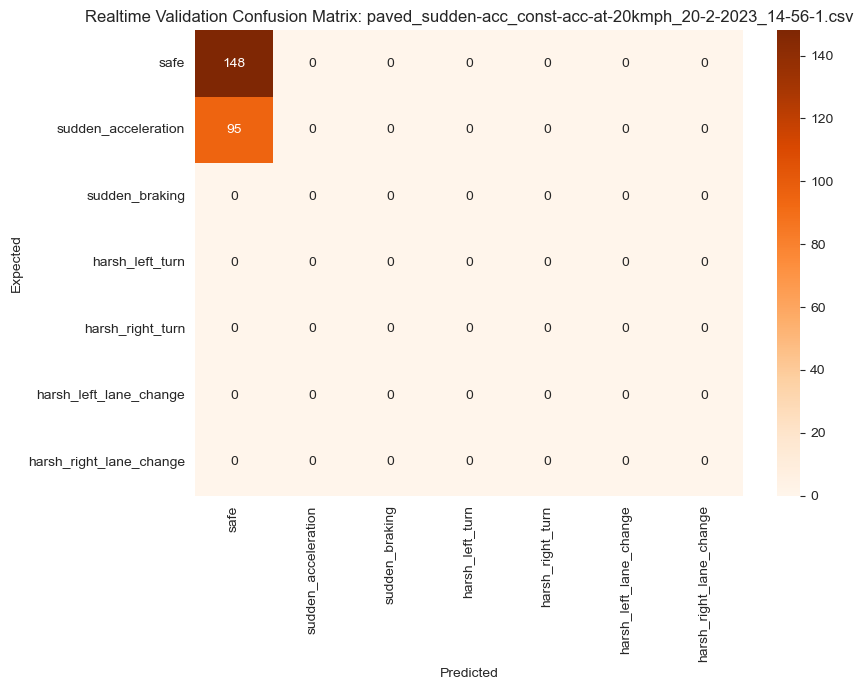

,idx,timestamp,expected_event,raw_prediction,prediction,confidence,correct
0,24,20-2-2023_14:56:30:493871,safe,safe,safe,0.8139,True
1,29,20-2-2023_14:56:30:749889,safe,safe,safe,0.8412,True
2,34,20-2-2023_14:56:31:5800,safe,safe,safe,0.8340,True
3,39,20-2-2023_14:56:31:269812,safe,safe,safe,0.8367,True
4,44,20-2-2023_14:56:31:525780,safe,safe,safe,0.8402,True
5,49,20-2-2023_14:56:31:781698,safe,safe,safe,0.8244,True
6,54,20-2-2023_14:56:32:45718,safe,harsh_right_lane_change,safe,0.8213,True
7,59,20-2-2023_14:56:32:301646,safe,safe,safe,0.8073,True
8,64,20-2-2023_14:56:32:565599,safe,safe,safe,0.8040,True
9,69,20-2-2023_14:56:32:821569,safe,safe,safe,0.7737,True


In [30]:
from harsh_event_model import EVENT_CLASSES, infer_event_from_filename, normalize_event_name

file_event = infer_event_from_filename(selected_csv.name)
if file_event == 'safe':
    active_event = normalize_event_name(stream_df['harsh_event'].mode(dropna=True).iloc[0])
else:
    active_event = file_event

validation_df = stream_df.copy()
validation_df['expected_row_label'] = np.where(
    pd.to_numeric(validation_df['event_class'], errors='coerce').fillna(0).astype(int) == 1,
    active_event,
    'safe',
)

validation_detector = RealtimeHarshEventDetector(
    model_bundle_path=rf_bundle_path,
    min_confidence=0.45,
    consecutive_hits=2,
)
validation_detector.model.named_steps['rf'].set_params(n_jobs=1)

realtime_records = []
for i, row in enumerate(validation_df.itertuples(index=False), start=0):
    packet = {c: float(getattr(row, c)) for c in imu_cols}
    result = validation_detector.update(packet)
    if not (isinstance(result, dict) and result.get('ready')):
        continue

    window_start = i - validation_detector.window_size + 1
    expected_window = validation_df.iloc[window_start : i + 1]['expected_row_label']
    non_safe = expected_window[expected_window != 'safe']
    if len(non_safe) == 0 or (len(non_safe) / validation_detector.window_size) < validation_detector.bundle['min_event_ratio']:
        expected_label = 'safe'
    else:
        expected_label = non_safe.value_counts().idxmax()

    realtime_records.append({
        'idx': i,
        'timestamp': getattr(row, 'timestamp', i),
        'expected_event': expected_label,
        'raw_prediction': result['raw_prediction'],
        'prediction': result['prediction'],
        'confidence': round(float(result['confidence']), 4),
        'correct': result['prediction'] == expected_label,
    })

realtime_eval_df = pd.DataFrame(realtime_records)
print(f'Validated windows from {selected_csv.name}: {len(realtime_eval_df)}')
print('Detection accuracy on streamed windows:', round(realtime_eval_df['correct'].mean(), 4))

print('First mismatches:')
display(realtime_eval_df.loc[~realtime_eval_df['correct']].head(10))

print('Realtime classification report:')
print(
    classification_report(
        realtime_eval_df['expected_event'],
        realtime_eval_df['prediction'],
        labels=EVENT_CLASSES,
        target_names=EVENT_CLASSES,
        digits=4,
        zero_division=0,
    )
)

cm_realtime = confusion_matrix(
    realtime_eval_df['expected_event'],
    realtime_eval_df['prediction'],
    labels=EVENT_CLASSES,
 )
plt.figure(figsize=(9, 7))
sns.heatmap(
    cm_realtime,
    annot=True,
    fmt='d',
    cmap='Oranges',
    xticklabels=EVENT_CLASSES,
    yticklabels=EVENT_CLASSES,
 )
plt.title(f'Realtime Validation Confusion Matrix: {selected_csv.name}')
plt.xlabel('Predicted')
plt.ylabel('Expected')
plt.tight_layout()
plt.show()

display(realtime_eval_df.head(20))

In [31]:
all_realtime_records = []
per_file_metrics = []

for candidate_csv in csv_files:
    eval_df = pd.read_csv(candidate_csv)
    for c in imu_cols:
        eval_df[c] = pd.to_numeric(eval_df[c], errors='coerce')
    eval_df = eval_df.dropna(subset=imu_cols).reset_index(drop=True)

    file_event = infer_event_from_filename(candidate_csv.name)
    if file_event == 'safe':
        active_event = normalize_event_name(eval_df['harsh_event'].mode(dropna=True).iloc[0])
    else:
        active_event = file_event

    eval_df['expected_row_label'] = np.where(
        pd.to_numeric(eval_df['event_class'], errors='coerce').fillna(0).astype(int) == 1,
        active_event,
        'safe',
    )

    detector = RealtimeHarshEventDetector(
        model_bundle_path=rf_bundle_path,
        min_confidence=0.45,
        consecutive_hits=2,
    )
    detector.model.named_steps['rf'].set_params(n_jobs=1)

    file_records = []
    for i, row in enumerate(eval_df.itertuples(index=False), start=0):
        packet = {c: float(getattr(row, c)) for c in imu_cols}
        result = detector.update(packet)
        if not (isinstance(result, dict) and result.get('ready')):
            continue

        window_start = i - detector.window_size + 1
        expected_window = eval_df.iloc[window_start : i + 1]['expected_row_label']
        non_safe = expected_window[expected_window != 'safe']
        if len(non_safe) == 0 or (len(non_safe) / detector.window_size) < detector.bundle['min_event_ratio']:
            expected_label = 'safe'
        else:
            expected_label = non_safe.value_counts().idxmax()

        record = {
            'file_name': candidate_csv.name,
            'idx': i,
            'expected_event': expected_label,
            'prediction': result['prediction'],
            'raw_prediction': result['raw_prediction'],
            'confidence': round(float(result['confidence']), 4),
            'correct': result['prediction'] == expected_label,
        }
        file_records.append(record)
        all_realtime_records.append(record)

    file_eval_df = pd.DataFrame(file_records)
    if file_eval_df.empty:
        continue

    per_file_metrics.append({
        'file_name': candidate_csv.name,
        'windows_evaluated': len(file_eval_df),
        'accuracy': round(file_eval_df['correct'].mean(), 4),
        'expected_non_safe_windows': int((file_eval_df['expected_event'] != 'safe').sum()),
        'predicted_non_safe_windows': int((file_eval_df['prediction'] != 'safe').sum()),
        'false_positive_windows': int(((file_eval_df['expected_event'] == 'safe') & (file_eval_df['prediction'] != 'safe')).sum()),
        'false_negative_windows': int(((file_eval_df['expected_event'] != 'safe') & (file_eval_df['prediction'] == 'safe')).sum()),
    })

all_realtime_eval_df = pd.DataFrame(all_realtime_records)
per_file_metrics_df = pd.DataFrame(per_file_metrics).sort_values(['accuracy', 'false_positive_windows', 'false_negative_windows'])

display(per_file_metrics_df.head(20))

print('Overall realtime classification report across all files:')
print(
    classification_report(
        all_realtime_eval_df['expected_event'],
        all_realtime_eval_df['prediction'],
        labels=EVENT_CLASSES,
        target_names=EVENT_CLASSES,
        digits=4,
        zero_division=0,
    )
)

overall_cm = confusion_matrix(
    all_realtime_eval_df['expected_event'],
    all_realtime_eval_df['prediction'],
    labels=EVENT_CLASSES,
 )
plt.figure(figsize=(9, 7))
sns.heatmap(
    overall_cm,
    annot=True,
    fmt='d',
    cmap='Purples',
    xticklabels=EVENT_CLASSES,
    yticklabels=EVENT_CLASSES,
 )
plt.title('Overall Realtime Validation Confusion Matrix Across All CSV Files')
plt.xlabel('Predicted')
plt.ylabel('Expected')
plt.tight_layout()
plt.show()

KeyboardInterrupt: 

## 15. Model Export and Runtime Integration Hooks

In [ ]:
# Runtime integration API stub for CARLA client usage.
def predict_event_from_packet(detector, packet):
    """
    packet schema expected:
    {
      'acc_x': float, 'acc_y': float, 'acc_z': float,
      'gyro_x': float, 'gyro_y': float, 'gyro_z': float,
      'mag_x': float, 'mag_y': float, 'mag_z': float
    }
    """
    return detector.update(packet)

print('Exported artifacts:')
for p in sorted(ARTIFACT_DIR.glob('*')):
    print('-', p.name)

print('\nSafety score integration hook:')
print('Consume emitted events (timestamp, event, confidence) to compute your scoring logic later.')

Exported artifacts:
- harsh_event_cnn_bilstm.pt
- harsh_event_rf.joblib
- harsh_event_rf_calibrated.joblib
- seq_training_history.csv
- split_manifest.csv

Safety score integration hook:
Consume emitted events (timestamp, event, confidence) to compute your scoring logic later.


Chosen 70/30 split seed: 43
Train size: 4369, Test size: 1804
Test label coverage: ['harsh_left_lane_change', 'harsh_left_turn', 'harsh_right_lane_change', 'harsh_right_turn', 'safe', 'sudden_acceleration', 'sudden_braking']
Chosen sudden_acceleration threshold: 0.33
Chosen sudden_braking threshold     : 0.28
Random Forest 70/30 cascade test report:
                         precision    recall  f1-score   support

 harsh_left_lane_change     0.4182    0.3407    0.3755       135
        harsh_left_turn     1.0000    0.1971    0.3293       137
harsh_right_lane_change     0.4217    0.3365    0.3743       104
       harsh_right_turn     0.9286    0.4062    0.5652        32
                   safe     0.7055    0.9671    0.8159      1095
    sudden_acceleration     0.6383    0.1395    0.2290       215
         sudden_braking     0.6818    0.1744    0.2778        86

               accuracy                         0.6790      1804
              macro avg     0.6849    0.3660    0.4239      1

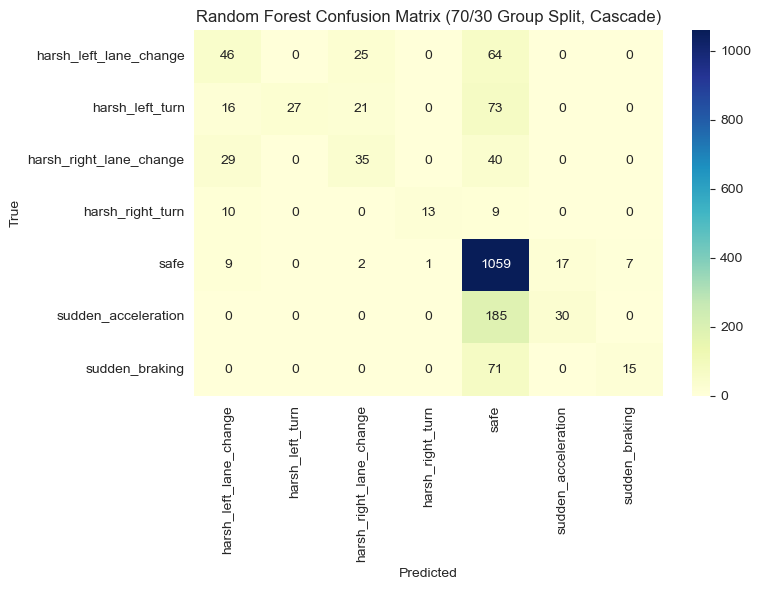

In [43]:
# --- Optional experiment: 70/30 grouped split with sudden-event cascade ---
from harsh_event_model import build_window_dataset
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier

X_df_7030, y_series_7030 = build_window_dataset(
    clean_df,
    window_size=WINDOW_SIZE,
    step_size=STEP_SIZE,
    min_event_ratio=0.20,
)

groups_7030 = groups.copy()
all_labels_7030 = sorted(pd.Series(y_series_7030).unique().tolist())
non_safe_labels_7030 = [lbl for lbl in all_labels_7030 if lbl != 'safe']

best_split_7030 = None
best_score_7030 = (-1, -1, -1)

# Find a 70/30 grouped split that covers non-safe classes well in test.
for split_seed_7030 in range(SEED, SEED + 5000):
    gss_7030 = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=split_seed_7030)
    train_idx_7030, test_idx_7030 = next(gss_7030.split(X_df_7030, y_series_7030, groups=groups_7030))

    y_test_tmp = y_series_7030.iloc[test_idx_7030]
    test_present = set(y_test_tmp.astype(str).unique().tolist())
    non_safe_cov = sum(lbl in test_present for lbl in non_safe_labels_7030)
    diversity = len(test_present)
    score = (non_safe_cov, diversity, len(test_idx_7030))

    if score > best_score_7030:
        best_score_7030 = score
        best_split_7030 = (train_idx_7030, test_idx_7030, split_seed_7030)

    if non_safe_cov == len(non_safe_labels_7030):
        break

if best_split_7030 is None:
    raise RuntimeError('Could not create 70/30 split.')

train_idx_7030, test_idx_7030, chosen_seed_7030 = best_split_7030
X_train_7030 = X_df_7030.iloc[train_idx_7030].reset_index(drop=True)
X_test_7030 = X_df_7030.iloc[test_idx_7030].reset_index(drop=True)
y_train_7030 = y_series_7030.iloc[train_idx_7030].reset_index(drop=True)
y_test_7030 = y_series_7030.iloc[test_idx_7030].reset_index(drop=True)

print(f'Chosen 70/30 split seed: {chosen_seed_7030}')
print(f'Train size: {len(X_train_7030)}, Test size: {len(X_test_7030)}')
print('Test label coverage:', sorted(pd.Series(y_test_7030).unique().tolist()))

# Encode labels.
le_7030 = LabelEncoder()
le_7030.fit(pd.concat([y_train_7030, y_test_7030], axis=0).astype(str))
y_train_enc_7030 = le_7030.transform(y_train_7030.astype(str))
y_test_enc_7030 = le_7030.transform(y_test_7030.astype(str))
class_names_7030 = list(le_7030.classes_)

safe_idx_7030 = int(np.where(le_7030.classes_ == 'safe')[0][0])
acc_idx_7030 = int(np.where(le_7030.classes_ == 'sudden_acceleration')[0][0]) if 'sudden_acceleration' in le_7030.classes_ else None
brk_idx_7030 = int(np.where(le_7030.classes_ == 'sudden_braking')[0][0]) if 'sudden_braking' in le_7030.classes_ else None

# Stage 1: dedicated binary detectors for sudden events.
def train_binary_event_detector(event_name: str, positive_label: str):
    y_binary = (y_train_7030.astype(str) == positive_label).astype(int).to_numpy()
    ros = RandomOverSampler(random_state=SEED)
    X_bal, y_bal = ros.fit_resample(X_train_7030, y_binary)
    clf = RandomForestClassifier(
        n_estimators=700,
        max_features='sqrt',
        class_weight={0: 1.0, 1: 4.0},
        random_state=SEED,
        n_jobs=-1,
    )
    clf.fit(X_bal, y_bal)
    return clf

acc_detector_7030 = train_binary_event_detector('sudden_acceleration', 'sudden_acceleration') if acc_idx_7030 is not None else None
brk_detector_7030 = train_binary_event_detector('sudden_braking', 'sudden_braking') if brk_idx_7030 is not None else None

# Stage 2: general multiclass model on all labels (used as fallback for turns + safe).
ros_general_7030 = RandomOverSampler(random_state=SEED)
X_general_bal_7030, y_general_bal_7030 = ros_general_7030.fit_resample(X_train_7030, y_train_enc_7030)

general_clf_7030 = RandomForestClassifier(
    n_estimators=1000,
    max_features='sqrt',
    class_weight='balanced_subsample',
    random_state=SEED,
    n_jobs=-1,
)
general_clf_7030.fit(X_general_bal_7030, y_general_bal_7030)

# Tune sudden-event thresholds on the training set by looking for the best F1 per detector.
def tune_binary_threshold(clf, X, y_true_binary):
    prob = clf.predict_proba(X)[:, 1]
    best_thr = 0.5
    best_f1 = -1.0
    for thr in np.linspace(0.10, 0.90, 33):
        pred = (prob >= thr).astype(int)
        tp = np.sum((pred == 1) & (y_true_binary == 1))
        fp = np.sum((pred == 1) & (y_true_binary == 0))
        fn = np.sum((pred == 0) & (y_true_binary == 1))
        precision = tp / (tp + fp + 1e-9)
        recall = tp / (tp + fn + 1e-9)
        f1 = 2 * precision * recall / (precision + recall + 1e-9)
        if f1 > best_f1:
            best_f1 = f1
            best_thr = thr
    return best_thr

acc_thr_7030 = 0.22
brk_thr_7030 = 0.18
if acc_detector_7030 is not None:
    y_acc_train_bin = (y_train_7030.astype(str) == 'sudden_acceleration').astype(int).to_numpy()
    acc_thr_7030 = tune_binary_threshold(acc_detector_7030, X_train_7030, y_acc_train_bin)
if brk_detector_7030 is not None:
    y_brk_train_bin = (y_train_7030.astype(str) == 'sudden_braking').astype(int).to_numpy()
    brk_thr_7030 = tune_binary_threshold(brk_detector_7030, X_train_7030, y_brk_train_bin)

# Final cascade prediction on test.
y_pred_7030 = []
proba_general_7030 = general_clf_7030.predict_proba(X_test_7030)
proba_acc_7030 = acc_detector_7030.predict_proba(X_test_7030)[:, 1] if acc_detector_7030 is not None else None
proba_brk_7030 = brk_detector_7030.predict_proba(X_test_7030)[:, 1] if brk_detector_7030 is not None else None

for i in range(len(X_test_7030)):
    acc_score = proba_acc_7030[i] if proba_acc_7030 is not None else 0.0
    brk_score = proba_brk_7030[i] if proba_brk_7030 is not None else 0.0

    if acc_score >= acc_thr_7030 and acc_score >= brk_score:
        y_pred_7030.append(acc_idx_7030)
        continue
    if brk_score >= brk_thr_7030 and brk_score > acc_score:
        y_pred_7030.append(brk_idx_7030)
        continue

    pred_general = int(np.argmax(proba_general_7030[i]))
    y_pred_7030.append(pred_general)

y_pred_7030 = np.array(y_pred_7030, dtype=int)

print(f'Chosen sudden_acceleration threshold: {acc_thr_7030:.2f}')
print(f'Chosen sudden_braking threshold     : {brk_thr_7030:.2f}')
print('Random Forest 70/30 cascade test report:')
print(
    classification_report(
        y_test_enc_7030,
        y_pred_7030,
        labels=np.arange(len(le_7030.classes_)),
        target_names=class_names_7030,
        digits=4,
        zero_division=0,
    )
)

cm_7030 = confusion_matrix(y_test_enc_7030, y_pred_7030, labels=np.arange(len(le_7030.classes_)))
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_7030,
    annot=True,
    fmt='d',
    cmap='YlGnBu',
    xticklabels=class_names_7030,
    yticklabels=class_names_7030,
)
plt.title('Random Forest Confusion Matrix (70/30 Group Split, Cascade)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()